In [ ]:
class BSMPricer:
  """
  Black-Scholes-Merton
  """
  @staticmethod
  def price_european(S0: float, K: float, T:float, r:float, sigma: float, opt_type: OptionType) ->float:
    """
    利用1文件中的理论推导，先用BSM方法进行连续情况的类似定价。
    """
    if T<=0 :
      if opt_type == OptionType.CALL:
        return max(0.0, S0 - K)
      else:
        return max(0.0, K - S0)

    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2)*T)/(sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if opt_type == OptionType.CALL:
      price = S0



In [ ]:
if __name__ == "__main__":
    pricer = PureDiscreteBinomialPricer(K=5.0, N=3, u=2.0, d=0.5, r=0.25)

    # 场景 A：t=0 时刻，股价 S=4.0
    price_put_A, delta_put_A = pricer.price_and_delta(0, 4.0, OptionType.PUT, ExerciseStyle.AMERICAN)

    print("--- 场景 A：t=0, S=4.0 ---")
    print(f"美式看跌期权价格: {price_put_A:.4f}")
    print(f"对冲比率 Delta : {delta_put_A:.4f}")
    print(f"操作含义: 为了对冲卖出 1 份看跌期权的风险，你今天需要卖空 {-delta_put_A:.4f} 份标的股票。\n")


--- 场景 A：t=0, S=4.0 ---
美式看跌期权价格: 1.3920
对冲比率 Delta : -0.4200
操作含义: 为了对冲卖出 1 份看跌期权的风险，你今天需要卖空 0.4200 份标的股票。



In [ ]:
import numpy as np
from enum import Enum

class OptionType(Enum):
    CALL = 1
    PUT = -1

class ExerciseStyle(Enum):
    EUROPEAN = 1
    AMERICAN = 2

class PureDiscreteBinomialPricer:
    """
    带有 Delta (对冲比率) 计算模块的离散二叉树定价引擎。
    """
    def __init__(self, K: float, N: int, u: float, d: float, r: float):
        self.K = K
        self.N = N
        self.u = u
        self.d = d
        self.r = r

        self.discount = 1.0 / (1.0 + self.r)
        self.p = (1.0 + self.r - self.d) / (self.u - self.d)

        if self.p <= 0 or self.p >= 1:
            raise ValueError(f"无套利条件被打破！要求 {d} < {1+r} < {u}，当前 p={self.p:.4f}")

    def price_and_delta(self, current_t: int, current_S: float, opt_type: OptionType, style: ExerciseStyle):
        """
        返回一个元组：(期权价格, 当前节点的对冲比率 Delta)
        """
        if current_t > self.N or current_t < 0:
            raise ValueError(f"当前时间点 {current_t} 无效，必须在 0 到 {self.N} 之间。")

        remaining_steps = self.N - current_t

        # --- 极端情况：期权已到期，不再需要动态对冲 ---
        if remaining_steps == 0:
            if opt_type == OptionType.CALL:
                val = max(0.0, current_S - self.K)
                delta = 1.0 if current_S > self.K else 0.0 # 实值看涨 Delta 为 1
                return val, delta
            else:
                val = max(0.0, self.K - current_S)
                delta = -1.0 if current_S < self.K else 0.0 # 实值看跌 Delta 为 -1
                return val, delta

        # --- 1. 生成到期日终端节点 ---
        j = np.arange(0, remaining_steps + 1)
        ST = current_S * (self.u ** j) * (self.d ** (remaining_steps - j))

        # --- 2. 计算终端收益 Payoff ---
        if opt_type == OptionType.CALL:
            V = np.maximum(0, ST - self.K)
        elif opt_type == OptionType.PUT:
            V = np.maximum(0, self.K - ST)

        # 初始化 delta
        delta = 0.0

        # --- 3. 离散贴现倒推求解 ---
        for i in range(remaining_steps - 1, -1, -1):

            # 【新增 Delta 计算板块】
            # 当倒推到最靠近当前时间点的那一层时 (即 i = 0)
            # 此时的 V[1] 就是上涨后的期权价值 V_u，V[0] 是下跌后的期权价值 V_d
            if i == 0:
                S_u = current_S * self.u
                S_d = current_S * self.d
                delta = (V[1] - V[0]) / (S_u - S_d)

            # 继续持有价值
            V_continuation = self.discount * (self.p * V[1:i+2] + (1 - self.p) * V[0:i+1])

            if style == ExerciseStyle.EUROPEAN:
                V = V_continuation

            elif style == ExerciseStyle.AMERICAN:
                j_current = np.arange(0, i + 1)
                S_current = current_S * (self.u ** j_current) * (self.d ** (i - j_current))

                if opt_type == OptionType.CALL:
                    V_intrinsic = np.maximum(0, S_current - self.K)
                else:
                    V_intrinsic = np.maximum(0, self.K - S_current)

                V = np.maximum(V_continuation, V_intrinsic)

        # 返回期权价格和 Delta
        return V[0], delta


BSM 解析解价格 (连续极限): 10.4506
正在计算二叉树价格，请稍候...


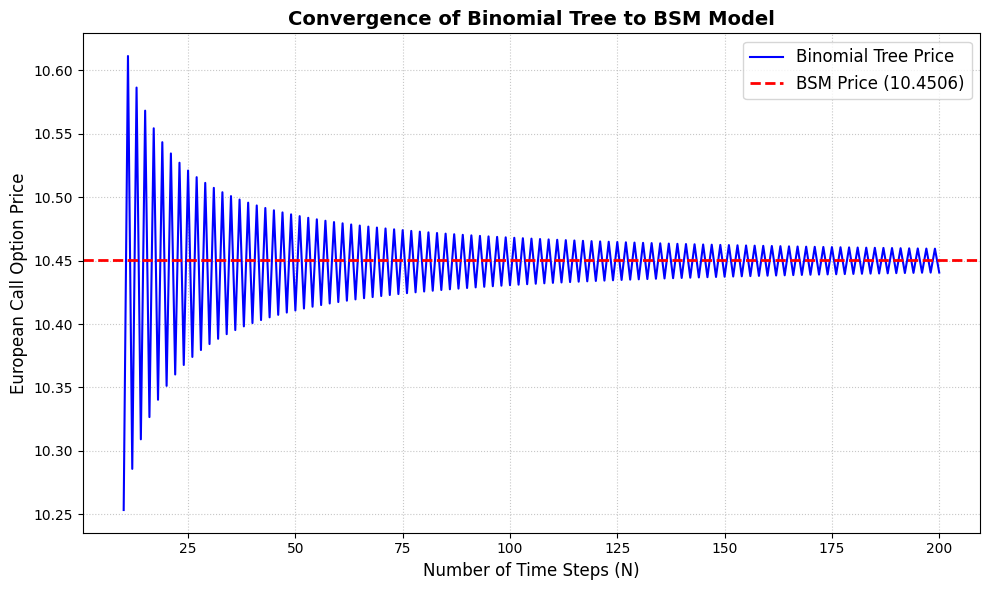

In [ ]:
import numpy as np
import scipy.stats as si
import matplotlib.pyplot as plt

# =========================================================
# 模块 1：连续时间 BSM 解析解 (作为收敛的绝对基准线)
# =========================================================
def bsm_european_call(S0, K, T, r, sigma):
    """
    计算 BSM 欧式看涨期权价格
    """
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    # si.norm.cdf 是标准正态分布的累积概率密度函数
    call_price = S0 * si.norm.cdf(d1) - K * np.exp(-r * T) * si.norm.cdf(d2)
    return call_price

# =========================================================
# 模块 2：动态 CRR 二叉树引擎 (根据步数 N 动态调整 u, d)
# =========================================================
def binomial_tree_european_call(S0, K, T, r, sigma, N):
    """
    使用 Numpy 向量化计算 CRR 二叉树欧式看涨期权价格。
    这里的参数必须由连续时间的 sigma 和 T/N 动态生成。
    """
    dt = T / N                                    # 每一小步的时间间隔
    u = np.exp(sigma * np.sqrt(dt))               # 随时间无限细分，u 逼近 1
    d = 1.0 / u                                   # 随时间无限细分，d 逼近 1
    discount = np.exp(-r * dt)                    # 连续复利下的单期折现因子
    p = (np.exp(r * dt) - d) / (u - d)            # 风险中性概率

    # 向量化生成终端股票价格数组 (长度为 N+1)
    j = np.arange(0, N + 1)
    ST = S0 * (u ** j) * (d ** (N - j))

    # 计算到期日 Payoff
    V = np.maximum(0, ST - K)

    # 动态规划倒推 (只需算欧式，所以非常快)
    for i in range(N - 1, -1, -1):
        V = discount * (p * V[1:i+2] + (1 - p) * V[0:i+1])

    return V[0]
# 模块 3：计算并绘制收敛图 (Convergence Plot)
def plot_convergence():
    # 1. 设定统一的市场参数
    S0 = 100.0      # 当前股价
    K = 100.0       # 行权价 (平值期权 At-the-money)
    T = 1.0         # 到期时间 (1年)
    r = 0.05        # 无风险利率 (5%)
    sigma = 0.20    # 波动率 (20%)

    # 2. 计算 BSM 绝对基准价格
    bsm_price = bsm_european_call(S0, K, T, r, sigma)
    print(f"BSM 解析解价格 (连续极限): {bsm_price:.4f}")

    # 3. 准备二叉树计算范围 (N 从 10 步到 200 步)
    # 注意：我们刻意使用连贯的步数，以观察二叉树特有的“奇偶震荡”现象
    steps_range = np.arange(10, 201, 1)
    tree_prices = []

    print("正在计算二叉树价格，请稍候...")
    for N in steps_range:
        price = binomial_tree_european_call(S0, K, T, r, sigma, N)
        tree_prices.append(price)

    # 4. 使用 Matplotlib 绘图
    plt.figure(figsize=(10, 6)) # 设置画布大小

    # 画出二叉树价格随步数 N 变化的曲线 (蓝色线)
    plt.plot(steps_range, tree_prices, label='Binomial Tree Price', color='blue', linewidth=1.5)

    # 画出 BSM 价格的水平基准线 (红色虚线)
    plt.axhline(y=bsm_price, color='red', linestyle='--', label=f'BSM Price ({bsm_price:.4f})', linewidth=2)

    # 设置图表格式 (为了防止中文乱码，图表标签使用英文)
    plt.title('Convergence of Binomial Tree to BSM Model', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Time Steps (N)', fontsize=12)
    plt.ylabel('European Call Option Price', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(loc='best', fontsize=12)

    # 紧凑布局并展示
    plt.tight_layout()
    plt.show()

# 执行绘图
if __name__ == "__main__":
    plot_convergence()


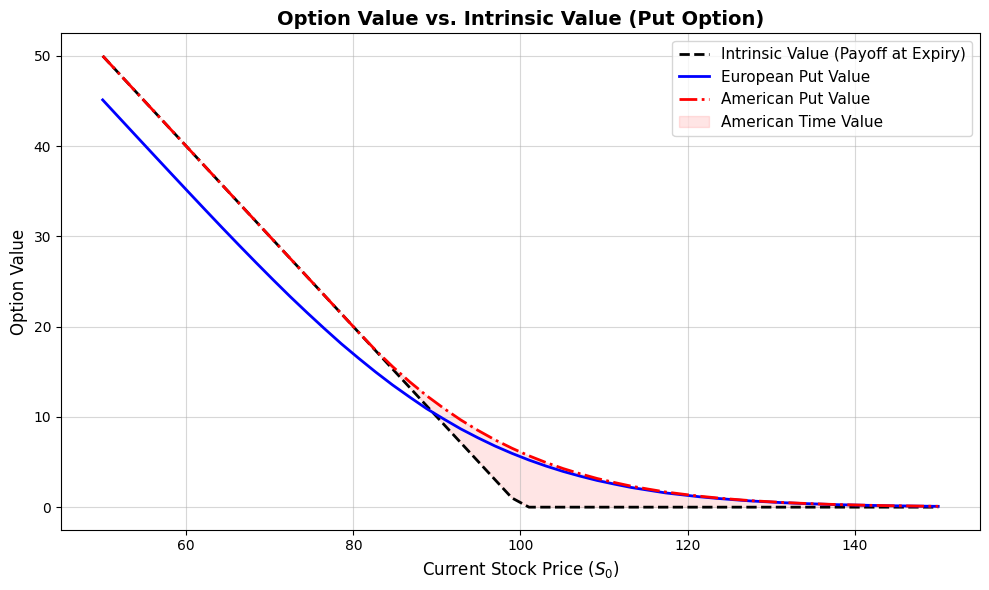

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 复用之前写的基础二叉树定价函数 (为了图表生成，写成一个紧凑的函数)
def compute_put_price(S0, K, T, r, sigma, N, is_american=False):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)
    discount = np.exp(-r * dt)

    j = np.arange(0, N + 1)
    ST = S0 * (u ** j) * (d ** (N - j))
    V = np.maximum(0, K - ST)

    for i in range(N - 1, -1, -1):
        V_cont = discount * (p * V[1:i+2] + (1 - p) * V[0:i+1])
        if is_american:
            S_curr = S0 * (u ** np.arange(0, i + 1)) * (d ** (i - np.arange(0, i + 1)))
            V_intr = np.maximum(0, K - S_curr)
            V = np.maximum(V_cont, V_intr)
        else:
            V = V_cont
    return V[0]

def plot_payoff_vs_value():
    K, T, r, sigma, N = 100, 1.0, 0.05, 0.2, 100

    # 构造不同的当前股价 S0 (从 50 到 150)
    S0_range = np.linspace(50, 150, 50)
    euro_prices = []
    amer_prices = []
    payoffs = np.maximum(0, K - S0_range)

    for S0 in S0_range:
        euro_prices.append(compute_put_price(S0, K, T, r, sigma, N, is_american=False))
        amer_prices.append(compute_put_price(S0, K, T, r, sigma, N, is_american=True))

    plt.figure(figsize=(10, 6))
    plt.plot(S0_range, payoffs, 'k--', linewidth=2, label='Intrinsic Value (Payoff at Expiry)')
    plt.plot(S0_range, euro_prices, 'b-', linewidth=2, label='European Put Value')
    plt.plot(S0_range, amer_prices, 'r-.', linewidth=2, label='American Put Value')

    # 填充时间价值区域
    plt.fill_between(S0_range, payoffs, amer_prices, color='red', alpha=0.1, label='American Time Value')

    plt.title('Option Value vs. Intrinsic Value (Put Option)', fontsize=14, fontweight='bold')
    plt.xlabel('Current Stock Price ($S_0$)', fontsize=12)
    plt.ylabel('Option Value', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_payoff_vs_value()


正在计算标准美式期权边界 (二叉树)，请稍候...
正在计算永久美式期权边界 (解析解)...
永久美式看跌期权的最优行权边界常数为: 71.4286


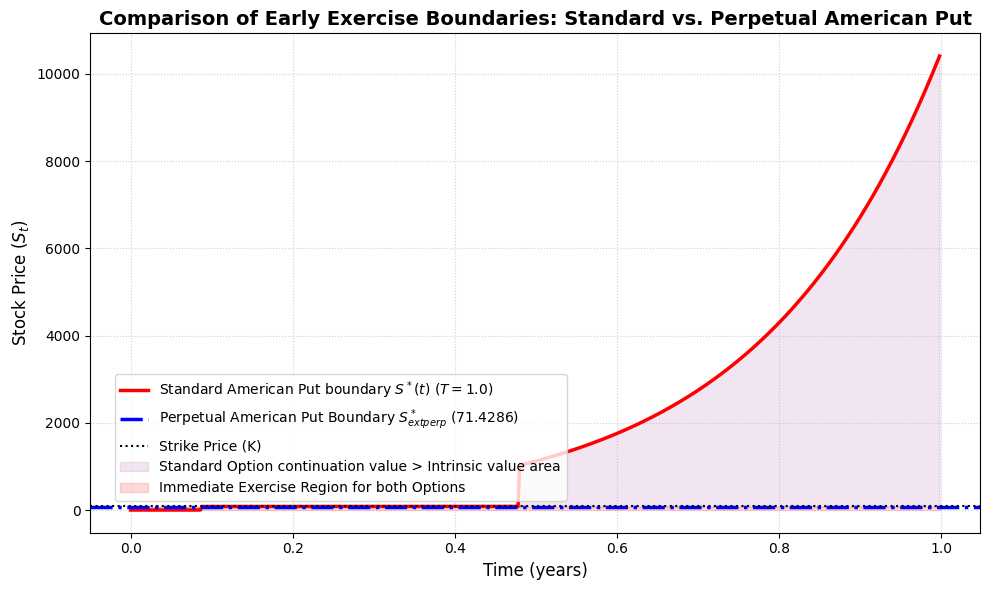

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# 模块 1：永久美式看跌期权的最优行权边界 (解析解)
def compute_perpetual_put_boundary(K, r, sigma):
    """
    根据 Shreve II 公式，计算永久美式看跌期权的常数行权边界 S*
    """
    # 辅助参数 gamma = 2r / sigma^2
    gamma = 2 * r / (sigma**2)
    # 最优行权边界公式
    S_star_perp = K * (gamma / (gamma + 1))
    return S_star_perp
# 模块 2：标准美式看跌期权的最优行权边界 (二叉树数值解)
def compute_standard_boundary_tree(S0, K, T, r, sigma, N):
    """
    复用之前的二叉树倒推逻辑，记录每一步的临界行权股价
    """
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)
    discount = np.exp(-r * dt)

    # 初始化到期日 V 和 ST
    j = np.arange(0, N + 1)
    ST = S0 * (u ** j) * (d ** (N - j))
    V = np.maximum(0, K - ST)

    boundary_S = []  # 记录每一步的临界股价
    time_steps = []  # 记录时间点 (从 0 到 T)

    # 动态规划倒推
    for i in range(N - 1, -1, -1):
        V_cont = discount * (p * V[1:i+2] + (1 - p) * V[0:i+1])

        # 当前层股票价格
        j_curr = np.arange(0, i + 1)
        S_curr = S0 * (u ** j_curr) * (d ** (i - j_curr))
        # 立即行权价值
        V_intr = np.maximum(0, K - S_curr)

        # 核心判断：寻找让内在价值 >= 继续持有价值的最高股价
        exercise_condition = V_intr >= V_cont

        if np.any(exercise_condition):
            # 找到满足行权条件的最大索引 (j越大股价越高)
            critical_idx = np.max(np.where(exercise_condition))
            critical_S = S_curr[critical_idx]
        else:
            critical_S = 0 # 如果都不满足，临界点设为0

        boundary_S.append(critical_S)
        time_steps.append(i * dt)

        # 更新 V 用于下一步倒推
        V = np.maximum(V_cont, V_intr)

    # 由于是倒推的，我们需要将结果反转回来以匹配正常时间流逝
    boundary_S.reverse()
    time_steps.reverse()
    return time_steps, boundary_S
# 模块 3：计算与绘图演示
if __name__ == "__main__":
    # 1. 设定统一的市场参数
    K = 100.0       # 行权价
    r = 0.05        # 无风险利率 (5%)
    sigma = 0.20    # 波动率 (20%)

    # 设定标准期权的到期时间和二叉树步数
    T_finite = 1.0  # 到期时间 (1年)
    N_steps = 500   # 步数设高一些，使边界线更平滑
    S0_tree_start = K * 1.2

    # 2. 计算标准美式期权的动态边界 S*(t)
    print("正在计算标准美式期权边界 (二叉树)，请稍候...")
    times_standard, boundary_standard = compute_standard_boundary_tree(
        S0_tree_start, K, T_finite, r, sigma, N_steps)

    # 3. 计算永久美式期权的常数边界 S*_perp
    print("正在计算永久美式期权边界 (解析解)...")
    S_star_perp = compute_perpetual_put_boundary(K, r, sigma)
    print(f"永久美式看跌期权的最优行权边界常数为: {S_star_perp:.4f}")

    # 4. 绘图对比
    plt.figure(figsize=(10, 6))

    # 画出标准美式边界线 (随时间流逝而上升的红线)
    plt.plot(times_standard, boundary_standard, 'r-', linewidth=2.5, label='Standard American Put boundary $S^*(t)$ ($T=1.0$)')

    # 画出永久美式边界线 (水平的蓝色直线)
    plt.axhline(y=S_star_perp, color='blue', linestyle='-.', linewidth=2.5, label=f'Perpetual American Put Boundary $S^*_{{\text{{perp}}}}$ ({S_star_perp:.4f})')

    # 画出行权价 K 的参考线
    plt.axhline(y=K, color='k', linestyle=':', label='Strike Price (K)')

    # 填充：两个边界之间的区域
    # 为了视觉清晰，我们将x轴范围稍微拉长，展示 T 无限大的收敛趋势
    plt.fill_between(times_standard, S_star_perp, boundary_standard, color='purple', alpha=0.1, label='Standard Option continuation value > Intrinsic value area')

    # 填充：只有有限到期期权才会行权的区域
    plt.fill_between(times_standard, 0, S_star_perp, color='red', alpha=0.15, label='Immediate Exercise Region for both Options')

    # 设置图表格式
    plt.title('Comparison of Early Exercise Boundaries: Standard vs. Perpetual American Put', fontsize=14, fontweight='bold')
    plt.xlabel('Time (years)', fontsize=12)
    plt.ylabel('Stock Price ($S_t$)', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='lower left', bbox_to_anchor=(0.02, 0.05), fontsize=10)
    plt.tight_layout()

    plt.show()
